In [1]:
!pip install wordcloud

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from slugify import slugify
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import matplotlib.dates as mdates

from striprtf.striprtf import rtf_to_text


In [3]:
trump_immigration_index1 = pd.read_excel('trump_and_immigration1_1000.xlsx')
trump_immigration_index2 = pd.read_excel('trump_and_immigration1001_2000.xlsx')
trump_immigration_index3 = pd.read_excel('trump_and_immigration2001_2811.xlsx')

trump_immigration_final = pd.concat([
    trump_immigration_index1,
    trump_immigration_index2,
    trump_immigration_index3
], ignore_index=True)


In [4]:
print("Combined DataFrame:")
print(trump_immigration_final.head())
print("Number of rows in final index:", len(trump_immigration_final))

trump_immigration_final.to_excel('trump_and_immigration_final.xlsx', index=False)
print("Final index saved successfully!")



Combined DataFrame:
                                               Title Published date  \
0  Inside the Trump administration's unprecedente...     2025-10-06   
1  Trump administration plans shake-up at ICE ami...     2025-10-28   
2  How federal agencies' roles have shifted in Tr...     2025-11-09   
3  Trump administration launches immigration enfo...     2025-09-07   
4  Chicago mayor signs order aimed at resisting T...     2025-08-30   

  Publication location Publication Publication type  Length Section  \
0         U.S. Federal    CNN Wire             News    1569     NaN   
1         U.S. Federal    CNN Wire             News     443     NaN   
2         U.S. Federal    CNN Wire             News    3153     NaN   
3         U.S. Federal    CNN Wire             News     599     NaN   
4         U.S. Federal    CNN Wire             News     903     NaN   

   Word count  Countries                                             Byline  \
0        1569        NaN                       

In [6]:
# ---------------------------------------------------
# Load converted text files
# ---------------------------------------------------

text_folder = "/Users/tiasiasaunders/Desktop/code/personal_code_projects/cj_final_project/file_raw_text"

files = [f for f in os.listdir(text_folder) if f.endswith(".txt")]

files_df = pd.DataFrame(files, columns=["filename"])

files_df["index"] = (
    files_df["filename"]
    .str.replace(".txt", "", regex=False)
    .apply(lambda x: slugify(x))
    .str[:25]
)

files_df = files_df.drop_duplicates(subset="index")

print("Files index:")
print(files_df.head())

Files index:
                                            filename  \
0  Trump is targeting the immigrants who will be ...   
1  Judge weighs halting Trump's National Guard de...   
2  Trump administration plans sweeping layoffs am...   
3  JB Pritzker Threatens To Arrest ICE Agents Pos...   
4  Donald Trump Squabbles With Federal Reserve Ch...   

                       index  
0  trump-is-targeting-the-im  
1  judge-weighs-halting-trum  
2  trump-administration-plan  
3  jb-pritzker-threatens-to-  
4  donald-trump-squabbles-wi  


In [7]:
excel_df = pd.read_excel("trump_and_immigration_final.xlsx")

excel_df.columns = excel_df.columns.str.lower().str.replace(" ", "_")

excel_df["index"] = (
    excel_df["title"]
    .astype(str)
    .apply(lambda x: slugify(x))
    .str[:25]
)

excel_df = excel_df.drop_duplicates(subset="index")

print("\nExcel index:")
print(excel_df.head())


Excel index:
                                               title published_date  \
0  Inside the Trump administration's unprecedente...     2025-10-06   
1  Trump administration plans shake-up at ICE ami...     2025-10-28   
2  How federal agencies' roles have shifted in Tr...     2025-11-09   
3  Trump administration launches immigration enfo...     2025-09-07   
4  Chicago mayor signs order aimed at resisting T...     2025-08-30   

  publication_location publication publication_type  length section  \
0         U.S. Federal    CNN Wire             News    1569     NaN   
1         U.S. Federal    CNN Wire             News     443     NaN   
2         U.S. Federal    CNN Wire             News    3153     NaN   
3         U.S. Federal    CNN Wire             News     599     NaN   
4         U.S. Federal    CNN Wire             News     903     NaN   

   word_count  countries                                             byline  \
0        1569        NaN                          By 

In [8]:

final_data = pd.merge(files_df, excel_df, on="index", how="inner")

print("\nMerged final data:")
print(final_data.head())
print(f"\nNumber of matched articles: {len(final_data)}")

final_data.to_csv("final_data.csv", index=False)
print("final_data saved as final_data.csv")


Merged final data:
                                            filename  \
0  Trump is targeting the immigrants who will be ...   
1  Judge weighs halting Trump's National Guard de...   
2  Trump administration plans sweeping layoffs am...   
3  JB Pritzker Threatens To Arrest ICE Agents Pos...   
4  Donald Trump Squabbles With Federal Reserve Ch...   

                       index  \
0  trump-is-targeting-the-im   
1  judge-weighs-halting-trum   
2  trump-administration-plan   
3  jb-pritzker-threatens-to-   
4  donald-trump-squabbles-wi   

                                               title published_date  \
0  Trump is targeting the immigrants who will be ...     2025-01-24   
1  Judge weighs halting Trump's National Guard de...     2025-10-03   
2  Trump administration plans shake-up at ICE ami...     2025-10-28   
3  JB Pritzker Threatens To Arrest ICE Agents Pos...     2025-10-15   
4  Donald Trump Squabbles With Federal Reserve Ch...     2025-07-24   

  publication_location 

In [9]:
final_data["filepath"] = text_folder + "/" + final_data["filename"]

print("\nFinal Data With Filepaths:")
print(final_data.head())


# Create an empty list to store rows
articles_list = []

# Loop through each row of final_data
for idx, row in final_data.iterrows():
    filepath = row["filepath"]
    filename = row["filename"]

    # Read all lines from the text file
    try:
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        continue

    # Append each line as a row with the filename
    for line in lines:
        # Strip newline characters
        line = line.strip()
        if line:  # skip empty lines
            articles_list.append({"filename": filename, "sentence": line})

# Create DataFrame from the list
articles_df = pd.DataFrame(articles_list)

print("Articles DataFrame head:")
print(articles_df.head())


Final Data With Filepaths:
                                            filename  \
0  Trump is targeting the immigrants who will be ...   
1  Judge weighs halting Trump's National Guard de...   
2  Trump administration plans sweeping layoffs am...   
3  JB Pritzker Threatens To Arrest ICE Agents Pos...   
4  Donald Trump Squabbles With Federal Reserve Ch...   

                       index  \
0  trump-is-targeting-the-im   
1  judge-weighs-halting-trum   
2  trump-administration-plan   
3  jb-pritzker-threatens-to-   
4  donald-trump-squabbles-wi   

                                               title published_date  \
0  Trump is targeting the immigrants who will be ...     2025-01-24   
1  Judge weighs halting Trump's National Guard de...     2025-10-03   
2  Trump administration plans shake-up at ICE ami...     2025-10-28   
3  JB Pritzker Threatens To Arrest ICE Agents Pos...     2025-10-15   
4  Donald Trump Squabbles With Federal Reserve Ch...     2025-07-24   

  publication_l

In [10]:
 #Join articles_df back to final_data on filename
articles_df = pd.merge(articles_df, final_data, on="filename", how="inner")

print("\nArticles DataFrame with metadata:")
print(articles_df.head())

# Optional: save to CSV
articles_df.to_csv("articles_df.csv", index=False)
print("Articles saved to articles_df.csv")

# Count unique articles
num_articles = articles_df["filename"].nunique()
print(f"Number of articles in articles_df: {num_articles}")



Articles DataFrame with metadata:
                                            filename  \
0  Trump is targeting the immigrants who will be ...   
1  Trump is targeting the immigrants who will be ...   
2  Trump is targeting the immigrants who will be ...   
3  Trump is targeting the immigrants who will be ...   
4  Trump is targeting the immigrants who will be ...   

                                            sentence  \
0  Trump is targeting the immigrants who will be ...   
1                                           CNN Wire   
2                January 24, 2025 Friday 9:00 AM GMT   
3  Copyright 2025 Cable News Network All Rights R...   
4                                  Length: 974 words   

                       index  \
0  trump-is-targeting-the-im   
1  trump-is-targeting-the-im   
2  trump-is-targeting-the-im   
3  trump-is-targeting-the-im   
4  trump-is-targeting-the-im   

                                               title published_date  \
0  Trump is targeting the i

In [11]:
import pandas as pd
articles_df = pd.read_csv("articles_df.csv")

In [12]:
# starting descriiptive statistics 

print("\nSummary of final_data:")
print(final_data.describe(include="all"))



Summary of final_data:
                                                 filename  \
count                                                2610   
unique                                               2610   
top     Trump is targeting the immigrants who will be ...   
freq                                                    1   
mean                                                  NaN   
min                                                   NaN   
25%                                                   NaN   
50%                                                   NaN   
75%                                                   NaN   
max                                                   NaN   
std                                                   NaN   

                            index  \
count                        2610   
unique                       2610   
top     trump-is-targeting-the-im   
freq                            1   
mean                          NaN   
min                  

In [13]:
print("\nSummary of articles_df:")
print(articles_df.describe(include="all"))


Summary of articles_df:
                                                 filename          sentence  \
count                                              384536            384536   
unique                                               2610            304941   
top     Trump Visits Texas After Devastating Floods; I...  (END VIDEO CLIP)   
freq                                                  637             14074   
mean                                                  NaN               NaN   
std                                                   NaN               NaN   
min                                                   NaN               NaN   
25%                                                   NaN               NaN   
50%                                                   NaN               NaN   
75%                                                   NaN               NaN   
max                                                   NaN               NaN   

                          

In [14]:
final_data['publication.1'].value_counts()

publication.1
CNN Wire                                                                                                                                                             1377
THE FIVE 5:00 PM EST                                                                                                                                                  134
FOX SPECIAL REPORT WITH BRET BAIER 6:00 PM EST                                                                                                                          8
LIFE, LIBERTY, LEVIN 8:00 PM EST                                                                                                                                        3
THE GREG GUTFELD SHOW 10:00 PM EST Jamie Lissow                                                                                                                         2
                                                                                                                                        

In [15]:
## classifying cnn and fox news for the final_data dataframe
def classify_source(value):
    val = str(value).upper()

    # CNN — since your column already has "cnn wire"
    if "CNN" in val:
        return "CNN Wire"
    
    # Fox News
    if "FOX" in val:
        return "Fox News"


    # Everything else
    return "Other"

final_data['source_category'] = final_data['publication'].apply(classify_source)


In [16]:
## classifying cnn and fox news for the articles_df dataframe

def classify_source(value):
    val = str(value).upper()

    # CNN — since your column already has "cnn wire"
    if "CNN" in val:
        return "CNN Wire"
    
    # Fox News
    if "FOX" in val:
        return "Fox News"
    

    # Everything else
    return "Other"

articles_df['source_category'] = articles_df['publication'].apply(classify_source)


In [17]:
import nltk
from nltk.corpus import stopwords
import string
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

import re

# Preprocess text to remove stopwords and punctuation, including contractions like n't
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation (anything not a word character or whitespace)
    text = re.sub(r"[^\w\s]", "", text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

cnn_tokens = preprocess_text(cnn_text)
fox_tokens = preprocess_text(fox_text)



[nltk_data] Downloading package punkt to
[nltk_data]     /Users/tiasiasaunders/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tiasiasaunders/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NameError: name 'cnn_text' is not defined

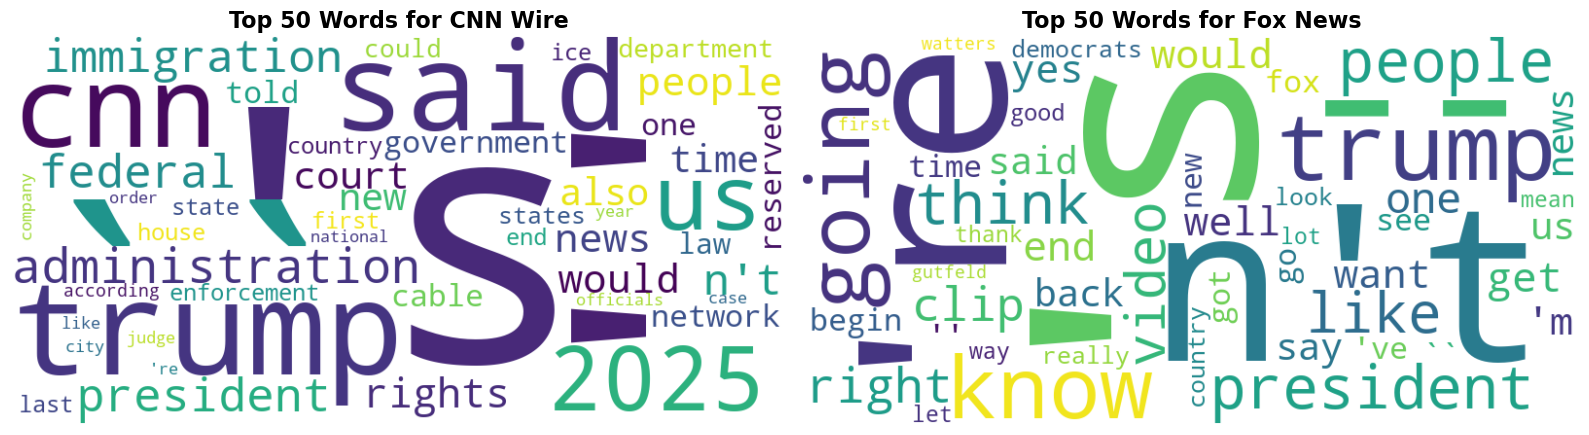

In [18]:
from wordcloud import WordCloud
from collections import Counter

import matplotlib.pyplot as plt

# Filter sentences by source category
cnn_sentences = articles_df[articles_df['source_category'] == 'CNN Wire']['sentence']
fox_sentences = articles_df[articles_df['source_category'] == 'Fox News']['sentence']

# Combine all sentences into a single string for each source
cnn_text = " ".join(cnn_sentences)
fox_text = " ".join(fox_sentences)

# Preprocess text to remove stopwords and punctuation
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]
    return tokens

cnn_tokens = preprocess_text(cnn_text)
fox_tokens = preprocess_text(fox_text)

# Get the top 50 words for each source
cnn_top_words = Counter(cnn_tokens).most_common(50)
fox_top_words = Counter(fox_tokens).most_common(50)

# Generate word clouds
cnn_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(cnn_top_words))
fox_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(fox_top_words))

# Plot the word clouds
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(cnn_wordcloud, interpolation='bilinear')
plt.title('Top 50 Words for CNN Wire', fontsize=16, weight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(fox_wordcloud, interpolation='bilinear')
plt.title('Top 50 Words for Fox News', fontsize=16, weight='bold')
plt.axis('off')

plt.savefig('wordclouds_cnn_fox.png', dpi=300)

plt.tight_layout()
plt.show()

In [19]:
print(cnn_top_words)

[("'s", 22106), ('``', 21538), ("''", 21452), ('trump', 13194), ('said', 11423), ('cnn', 9823), ('us', 5787), ('2025', 5756), ('administration', 4875), ('president', 4524), ('federal', 4492), ('immigration', 4474), ("n't", 4093), ('rights', 3628), ('would', 3528), ('news', 3518), ('people', 3474), ('court', 3265), ('new', 3180), ('also', 3138), ('time', 3062), ('government', 2914), ('one', 2870), ('network', 2861), ('told', 2848), ('reserved', 2780), ('cable', 2777), ('law', 2502), ('department', 2500), ('could', 2386), ('states', 2213), ('enforcement', 2196), ('state', 2188), ('house', 2146), ('ice', 2135), ('end', 2132), ('first', 2116), ('last', 2077), ('country', 2051), ('according', 2025), ('national', 1829), ('judge', 1797), ("'re", 1797), ('city', 1720), ('like', 1709), ('case', 1689), ('company', 1656), ('year', 1650), ('officials', 1631), ('order', 1616)]


In [20]:
print(fox_top_words)

[("'s", 155145), ("n't", 60125), ("'re", 53187), ('--', 47509), ('trump', 46886), ('going', 40954), ('know', 39570), ('president', 37591), ('people', 36679), ('think', 35764), ('like', 33937), ('video', 31146), ('right', 29817), ('clip', 29139), ('one', 23417), ('get', 22224), ('end', 21142), ('would', 20232), ('well', 20164), ('yes', 20064), ('want', 20031), ("'m", 18771), ('news', 17587), ('back', 17360), ('said', 17009), ('us', 16721), ('say', 16643), ('begin', 16159), ('see', 16137), ('new', 15643), ('fox', 15273), ('go', 14984), ("'ve", 14971), ('time', 14810), ('got', 14761), ('``', 14751), ("''", 14555), ('really', 13987), ('democrats', 13897), ('look', 13747), ('country', 13548), ('good', 12965), ('lot', 12127), ('thank', 12050), ('mean', 12021), ('way', 11968), ('let', 11593), ('gutfeld', 11565), ('first', 11370), ('watters', 11352)]


In [21]:
final_data['source_category'].value_counts()

source_category
CNN Wire    1377
Fox News    1233
Name: count, dtype: int64

In [22]:
source_counts = final_data['source_category'].value_counts().reset_index()
source_counts.columns = ['source_category', 'count']

/var/folders/6w/sgrmrps15mdf4l6v1k79k5bc0000gn/T/ipykernel_18644/3332570958.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_counts, x='source_category', y='count', palette=palette)


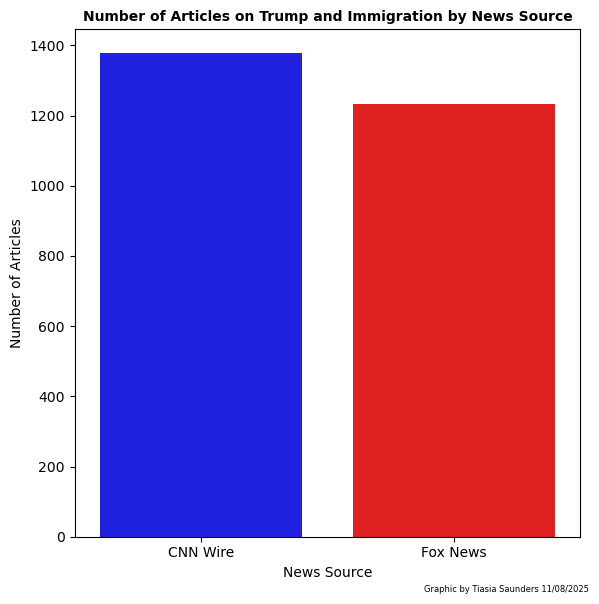

In [23]:
## plotting the graph 

custom_colors = {
    'CNN Wire': 'blue',
    'Fox News': 'red',
    'Other': 'gray'
}

# Count categories
source_counts = final_data['source_category'].value_counts().reset_index()
source_counts.columns = ['source_category', 'count']

# Map colors in the same order as the source_counts rows
palette = [custom_colors[cat] for cat in source_counts['source_category']]

# Plot
plt.figure(figsize=(6,6))
sns.barplot(data=source_counts, x='source_category', y='count', palette=palette)

plt.title('Number of Articles on Trump and Immigration by News Source', fontsize=10, weight='bold')
plt.xlabel('News Source')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)

plt.figtext(0.99, 0.005, "Graphic by Tiasia Saunders 11/08/2025",
            horizontalalignment='right', fontsize=6)
            

# Save the figure
plt.savefig("article_count_by_source_type.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


In [24]:
# Ensure 'published_date' is datetime
final_data['published_date'] = pd.to_datetime(final_data['published_date'])

# Group by month and source
monthly_counts = (
    final_data
    .groupby([final_data['published_date'].dt.to_period('M'), 'source_category'])
    .size()
    .reset_index(name='count')
)

# Convert Period back to datetime for plotting
monthly_counts['published_date'] = monthly_counts['published_date'].dt.to_timestamp()


In [25]:

print(monthly_counts)
monthly_counts.to_csv('monthly_counts.csv', index=False)

   published_date source_category  count
0      2025-01-01        CNN Wire    105
1      2025-01-01        Fox News     65
2      2025-02-01        CNN Wire    133
3      2025-02-01        Fox News    112
4      2025-03-01        CNN Wire    134
5      2025-03-01        Fox News    123
6      2025-04-01        CNN Wire    172
7      2025-04-01        Fox News    150
8      2025-05-01        CNN Wire    134
9      2025-05-01        Fox News    122
10     2025-06-01        CNN Wire    172
11     2025-06-01        Fox News    141
12     2025-07-01        CNN Wire    112
13     2025-07-01        Fox News    152
14     2025-08-01        CNN Wire    116
15     2025-08-01        Fox News    107
16     2025-09-01        CNN Wire    150
17     2025-09-01        Fox News    103
18     2025-10-01        CNN Wire    118
19     2025-10-01        Fox News    123
20     2025-11-01        CNN Wire     31
21     2025-11-01        Fox News     35


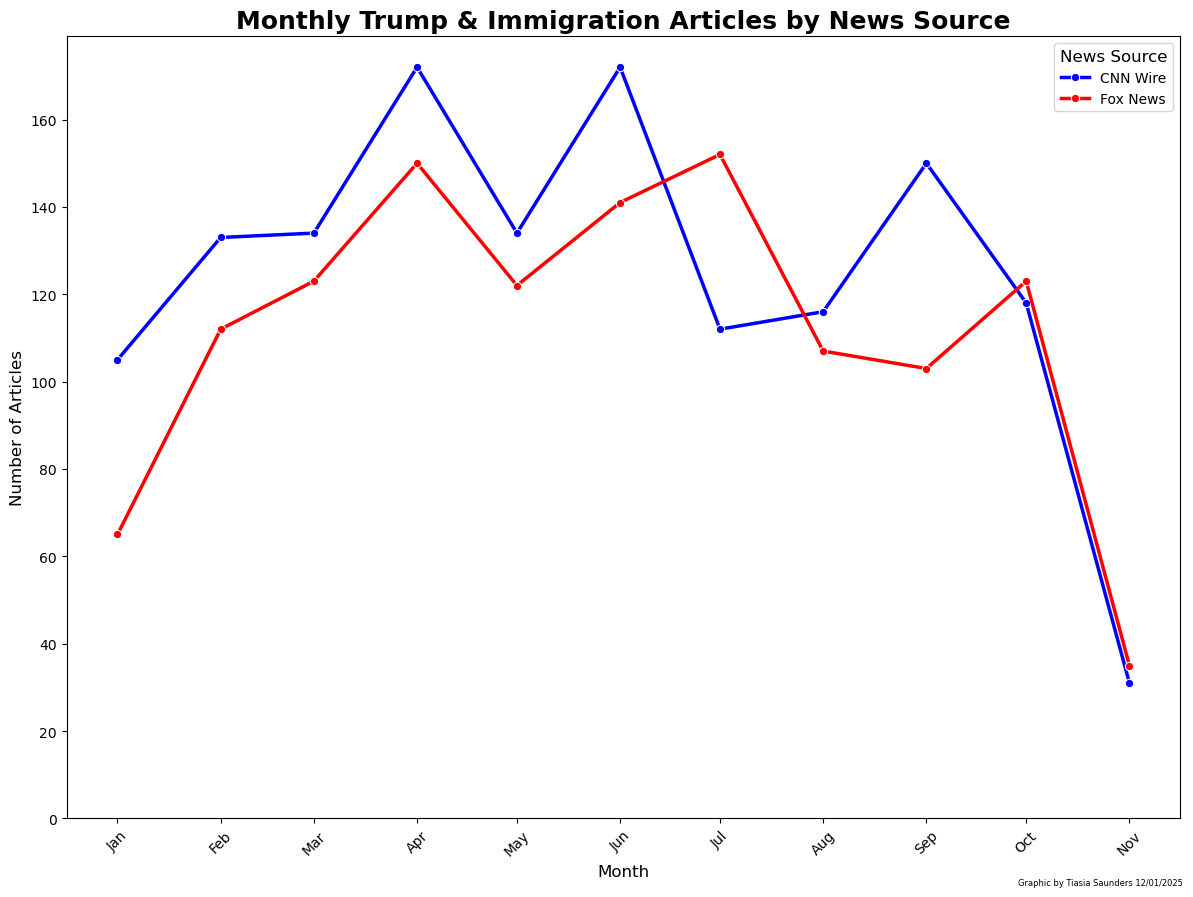

In [ ]:

# Plot
plt.figure(figsize=(12,9))

sns.lineplot(
    data=monthly_counts,
    x='published_date',
    y='count',
    hue='source_category',
    linewidth=2.5,           # slightly thicker lines
    palette={'CNN Wire': 'blue', 'Fox News': 'red'},
    marker='o'               # markers for each month
)

# Title and labels
plt.title('Monthly Trump & Immigration Articles by News Source', fontsize=18, weight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)

# Format x-axis to show abbreviated months
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Jan, Feb, Mar
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())        # show every month
plt.xticks(rotation=45)

# Legend customization
plt.legend(title='News Source', title_fontsize=12, fontsize=10)

# Y-axis starting at 0 for clarity
plt.ylim(bottom=0)

# Smaller attribution text
plt.figtext(0.99, 0.01, "Graphic by Tiasia Saunders 12/01/2025",
            horizontalalignment='right', fontsize=6)


# Save the figure
plt.savefig("article_count_over_time.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()




In [27]:
import nltk

# Download the missing resource
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/tiasiasaunders/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
## starting analysis of sentiment analysis, did the rest of the code block in google collab to avoid storage issues

import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

articles_df['clean_text'] = articles_df['sentence'].apply(preprocess)

print(articles_df[['sentence', 'clean_text']].head())



                                            sentence  \
0  Trump is targeting the immigrants who will be ...   
1                                           CNN Wire   
2                January 24, 2025 Friday 9:00 AM GMT   
3  Copyright 2025 Cable News Network All Rights R...   
4                                  Length: 974 words   

                                          clean_text  
0       trump targeting immigrants called rebuild la  
1                                           cnn wire  
2                     january 24 2025 friday 900 gmt  
3  copyright 2025 cable news network rights reserved  
4                                   length 974 words  


In [ ]:
# Apply to your DataFrame
articles_df['tokens'] = articles_df['sentence'].apply(preprocess)

# Look at the first 5 rows
print(articles_df[['sentence', 'tokens']].head())

In [ ]:
## put this code chunk in google collab to avoid crashing
import torch
from transformers import pipeline

In [43]:
## put this code chunk in google collab to avoid crashing
def get_sentiment(text):
    result = sentiment_model(text[:512])
    return result[0]['label'], result[0]['score']

In [ ]:
## put this code chunk in google collab to avoid crashing, got this snippet from Chat GPT 
import torch
from transformers import pipeline
import pandas as pd
import time

# Load sentiment analysis pipeline
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1  # use CPU
)

# Safe function to get sentiment from a text
def get_sentiment_safe(text):
    try:
        if not isinstance(text, str) or len(text.strip()) == 0:
            return pd.Series(["NEUTRAL", 0.0])
        # Truncate text to 256 characters to save memory
        truncated_text = text[:256]
        result = sentiment_model(truncated_text)
        return pd.Series([result[0]["label"], result[0]["score"]])
    except Exception as e:
        print(f"Error processing text: {e}")
        return pd.Series(["ERROR", 0.0])

# Process in **small batches** to prevent crashing
batch_size = 50  # adjust lower if still crashing
sentiment_labels = []
sentiment_scores = []

for i in range(0, len(articles_df), batch_size):
    batch = articles_df['sentence'].iloc[i:i+batch_size]
    output = batch.apply(get_sentiment_safe)
    
    sentiment_labels.extend(output[0])
    sentiment_scores.extend(output[1])
    
    print(f"Processed rows {i}–{i+batch_size}")
    time.sleep(1.0)  # small pause to reduce memory strain

# Attach results to dataframe
articles_df['sentiment_label'] = sentiment_labels
articles_df['sentiment_score'] = sentiment_scores

# Check summary by source_category
sentiment_summary = articles_df.groupby('source_category')['sentiment_score'].mean()
print(sentiment_summary)


Device set to use cpu


: 